# Computational Statistical Mechanics

Monte Carlo Rejection Algorithm for Activity Selection

simulations = 10000

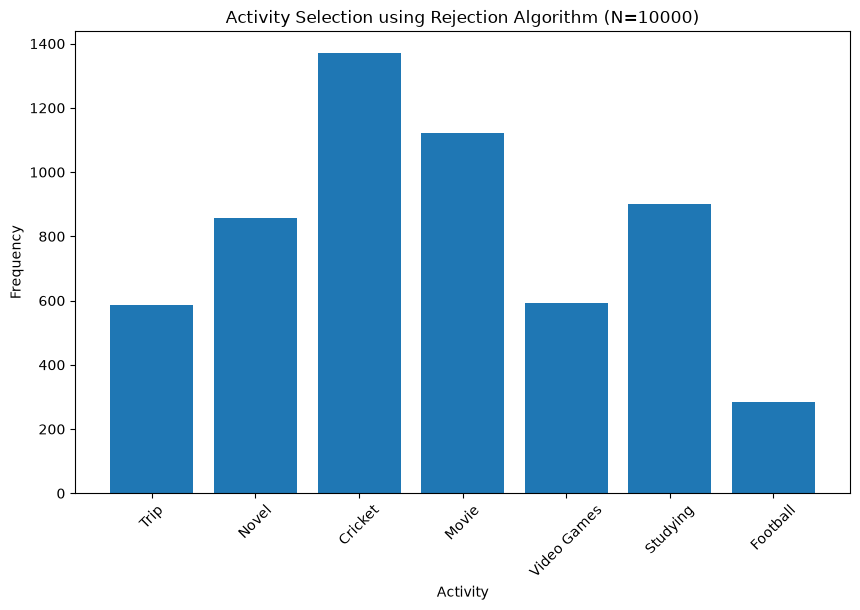

Rejection Algorithm Results

Activity  | Expected Count | Actual Count
Trip         |         1000 |        587
Novel        |         1500 |        857
Cricket      |         2500 |       1370
Movie        |         2000 |       1122
Video Games  |         1000 |        593
Studying     |         1500 |        901
Football     |          500 |        284


In [5]:
import random
import matplotlib.pyplot as plt
import numpy as np

activities = ['Trip', 'Novel', 'Cricket', 'Movie', 'Video Games', 'Studying', 'Football']
probabilities = [0.1, 0.15, 0.25, 0.2, 0.1, 0.15, 0.05]


def rejection_sampling(N):
    results=[]
    max_prob = max(probabilities)

    for i in range(N):
        u = random.uniform(0,max_prob)
        z = random.randint(0,len(activities)-1)

        #acceptance
        if u <= probabilities[z]:
            results.append(activities[z])
    
    return results

N=10000
Results = rejection_sampling(10000)

plt.figure(figsize=(10,6))
act_count = [Results.count(act) for act in activities]

plt.bar(activities,act_count)
plt.title('Activity Selection using Rejection Algorithm (N={0})'.format(N))
plt.xlabel('Activity')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

print("Rejection Algorithm Results")
print("\nActivity  | Expected Count | Actual Count")
for i, act in enumerate(activities):
    expected = probabilities[i] * N
    actual = Results.count(act)
    print("{0:12} | {1:12.0f} | {2:10}".format(act, expected, actual))


# Rejection-free Monte Carlo (tower sampling)

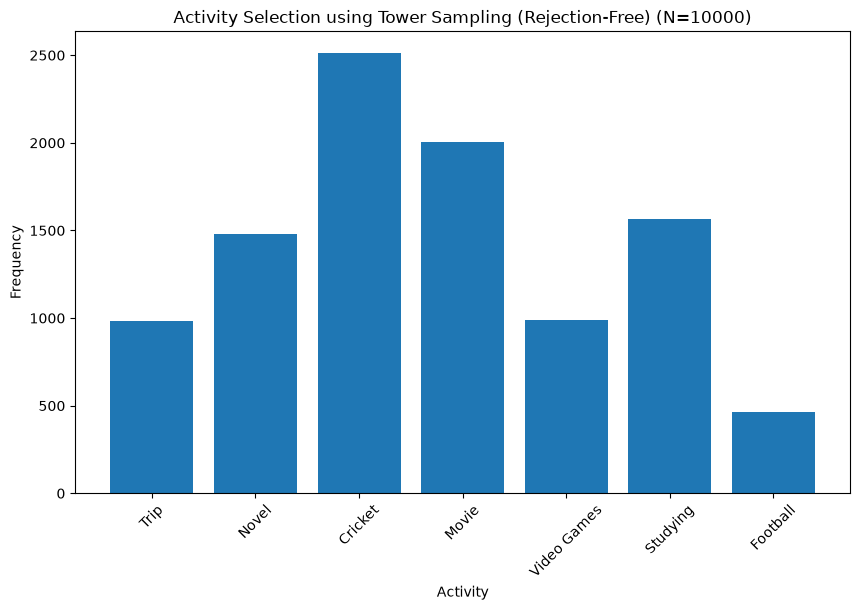

Tower Sampling (Rejection-Free) Results

Activity    | Expected Count | Actual Count
Trip         |         1000 |        982 
Novel        |         1500 |       1480 
Cricket      |         2500 |       2511 
Movie        |         2000 |       2005 
Video Games  |         1000 |        990 
Studying     |         1500 |       1566 
Football     |          500 |        466 


In [6]:
import random
import matplotlib.pyplot as plt
import numpy as np

activities = ['Trip', 'Novel', 'Cricket', 'Movie', 'Video Games', 'Studying', 'Football']
probabilities = [0.1, 0.15, 0.25, 0.2, 0.1, 0.15, 0.05]


def tower_sampling(N):
    results = []

    Pi = [0] * (len(probabilities) + 1)
    for l in range(1, len(probabilities) + 1):
        Pi[l] = Pi[l-1] + probabilities[l-1]
    
    for i in range(N):
        gamma = random.uniform(0, Pi[-1])
        
        for k in range(1, len(Pi)):
            if gamma <= Pi[k]:
                results.append(activities[k-1])
                break
    
    return results

N=10000
Results_tower = tower_sampling(N)

plt.figure(figsize=(10, 6))
activity_count_tower = [Results_tower.count(act) for act in activities]
plt.bar(activities, activity_count_tower)
plt.title('Activity Selection using Tower Sampling (Rejection-Free) (N={0})'.format(N))
plt.xlabel('Activity')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

print("Tower Sampling (Rejection-Free) Results")
print("\nActivity    | Expected Count | Actual Count")
for i, act in enumerate(activities):
    expected = probabilities[i] * N
    actual = Results_tower.count(act)
    print("{0:12} | {1:12.0f} | {2:10} ".format(act, expected, actual))


# 2) Disk Motion with Wall Collision Detection

without perodic boundary condition

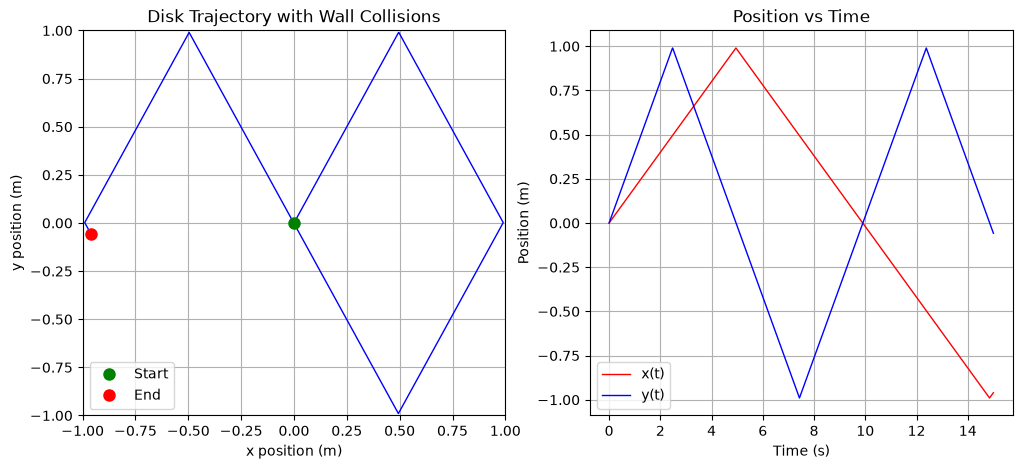

In [5]:
import numpy as np
import matplotlib.pyplot as plt

class Disk:
    def __init__(self, x, y, vx, vy, radius):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy
        self.radius = radius

    def new_pos(self, dt):
        #  x = x + v dt
        self.x += self.vx * dt
        self.y += self.vy * dt

    def wall_collision(self, box):
        # Left wall
        if self.x - self.radius < -box / 2:
            self.x = -box / 2 + self.radius
            self.vx = -self.vx

        # Right wall
        if self.x + self.radius > box / 2:
            self.x = box / 2 - self.radius
            self.vx = -self.vx

        # Bottom wall
        if self.y - self.radius < -box / 2:
            self.y = -box / 2 + self.radius
            self.vy = -self.vy

        # Top wall
        if self.y + self.radius > box / 2:
            self.y = box / 2 - self.radius
            self.vy = -self.vy


def Simulation(dt, t_total):

    disk = Disk(x=0, y=0, vx=0.2, vy=0.4, radius=0.01)

    x_pos = []
    y_pos = []
    times = []

    t = 0

    while t <= t_total:

        x_pos.append(disk.x)
        y_pos.append(disk.y)
        times.append(t)

        disk.new_pos(dt)
        disk.wall_collision(box=2.0)

        t += dt

    return x_pos, y_pos, times


X, Y, T = Simulation(dt=0.01, t_total=15)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(X, Y, 'b-', linewidth=1)
plt.plot(X[0], Y[0], 'go', markersize=8, label='Start')
plt.plot(X[-1], Y[-1], 'ro', markersize=8, label='End')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.title('Disk Trajectory with Wall Collisions')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(T, X, 'r-', label='x(t)', linewidth=1)
plt.plot(T, Y, 'b-', label='y(t)', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Position vs Time')
plt.legend()
plt.grid(True)

plt.show()

with perodic boundary condtion

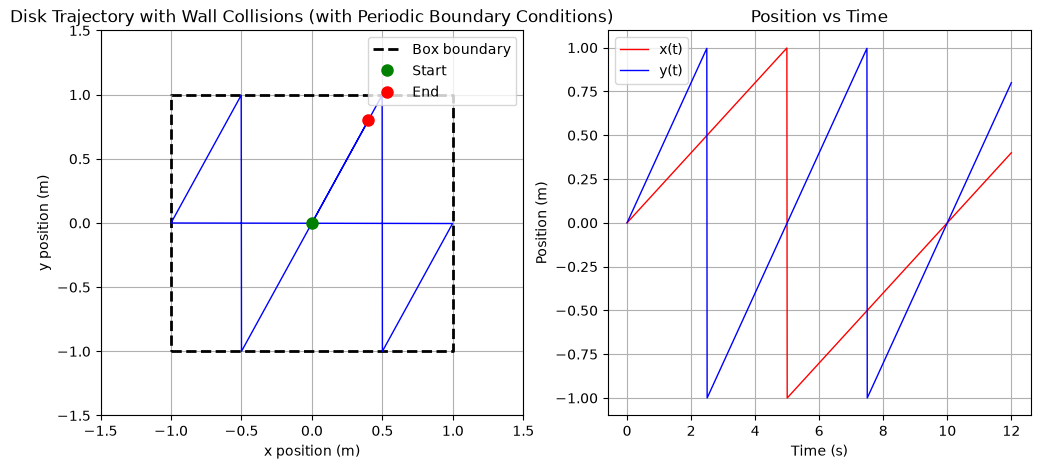

In [9]:
import numpy as np
import matplotlib.pyplot as plt

class PeriodicDisk:
    def __init__(self, x, y, vx, vy, radius):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy
        self.radius = radius

    def new_pos(self, dt):
        #  x = x + v dt
        self.x += self.vx * dt
        self.y += self.vy * dt

    def Collison_periodic(self, box):
        # Apply periodic boundary conditions
        half_box = box/ 2
        
        if self.x > half_box:
            self.x = -half_box + (self.x - half_box)
        if self.x < -half_box:
            self.x = half_box - (-half_box - self.x)
        if self.y > half_box:
            self.y = -half_box + (self.y - half_box)
        if self.y < -half_box:
            self.y = half_box - (-half_box - self.y)



def simulate_periodic_disk(dt, t_total):
    disk = PeriodicDisk(x=0, y=0, vx=0.2, vy=0.4, radius=0.01)
    
    x_pos = []
    y_pos = []
    times = []
    
    t = 0
    while t <= t_total:
        x_pos.append(disk.x)
        y_pos.append(disk.y)
        times.append(t)
        
        disk.new_pos(dt)
        disk.Collison_periodic(box=2.0)
        
        t = t + dt
    
    return x_pos, y_pos, times


X, Y, T = simulate_periodic_disk(dt=0.01, t_total=12)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], 'k--', linewidth=2, label='Box boundary')
plt.plot(X, Y, 'b-', linewidth=1)
plt.plot(X[0], Y[0], 'go', markersize=8, label='Start')
plt.plot(X[-1], Y[-1], 'ro', markersize=8, label='End')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.title('Disk Trajectory with Wall Collisions (with Periodic Boundary Conditions)')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(T, X, 'r-', label='x(t)', linewidth=1)
plt.plot(T, Y, 'b-', label='y(t)', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Position vs Time')
plt.legend()
plt.grid(True)

plt.show()